In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor, LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/Project/automobiles.csv')

In [ ]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [ ]:
df = df.replace('?', np.nan)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
df.shape

(205, 26)

In [ ]:
df = df.dropna(subset=['price'])
df['price'] = pd.to_numeric(df['price'])

In [ ]:
test_case_row = df.iloc[[0]].copy()
df = df.iloc[1:].copy()

In [ ]:
real_num_cols = ['normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight',
                 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower',
                 'peak-rpm', 'city-mpg', 'highway-mpg']

In [ ]:
for col in real_num_cols:
    df[col] = pd.to_numeric(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          200 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               200 non-null    object 
 3   fuel-type          200 non-null    object 
 4   aspiration         200 non-null    object 
 5   num-of-doors       198 non-null    object 
 6   body-style         200 non-null    object 
 7   drive-wheels       200 non-null    object 
 8   engine-location    200 non-null    object 
 9   wheel-base         200 non-null    float64
 10  length             200 non-null    float64
 11  width              200 non-null    float64
 12  height             200 non-null    float64
 13  curb-weight        200 non-null    int64  
 14  engine-type        200 non-null    object 
 15  num-of-cylinders   200 non-null    object 
 16  engine-size        200 non-null

In [ ]:
imputer = SimpleImputer(strategy='median')
df[real_num_cols] = imputer.fit_transform(df[real_num_cols])

### Exploratory Data Analysis (EDA)

Let's start by visualizing the distribution of the target variable, `price`.

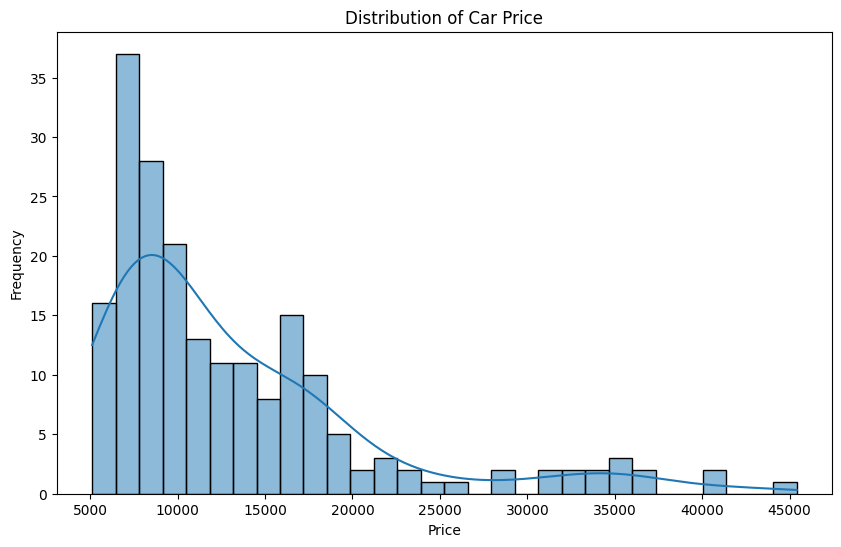

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Car Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Now, let's look at the distributions of some other key numerical features like 'horsepower', 'engine-size', and 'city-mpg'.

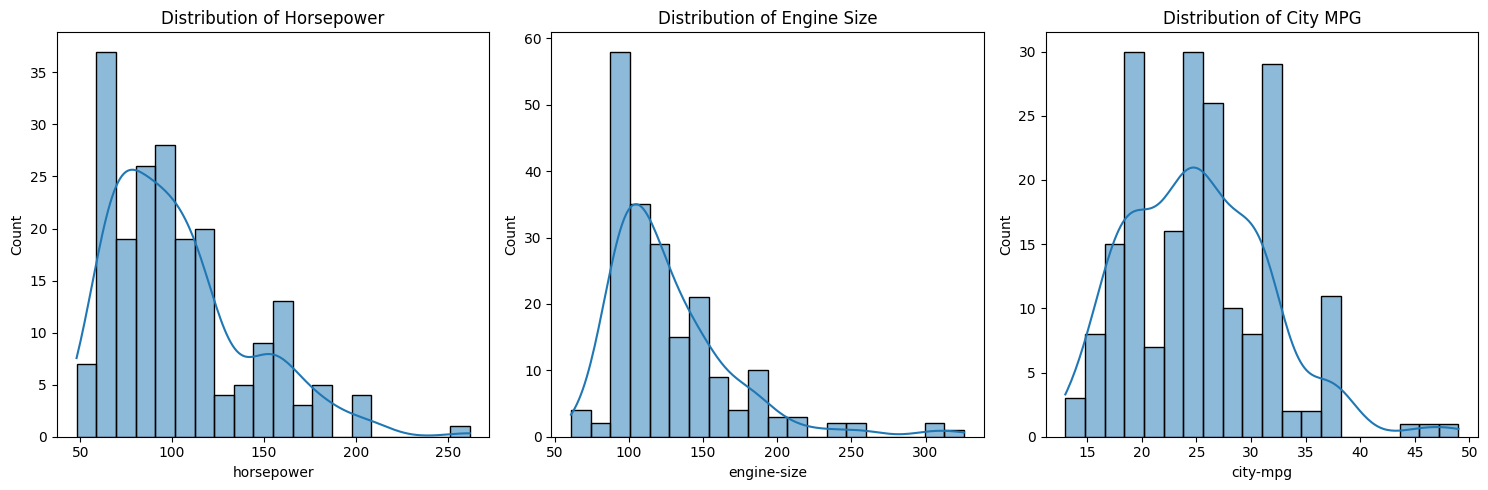

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['horsepower'], bins=20, kde=True)
plt.title('Distribution of Horsepower')

plt.subplot(1, 3, 2)
sns.histplot(df['engine-size'], bins=20, kde=True)
plt.title('Distribution of Engine Size')

plt.subplot(1, 3, 3)
sns.histplot(df['city-mpg'], bins=20, kde=True)
plt.title('Distribution of City MPG')

plt.tight_layout()
plt.show()

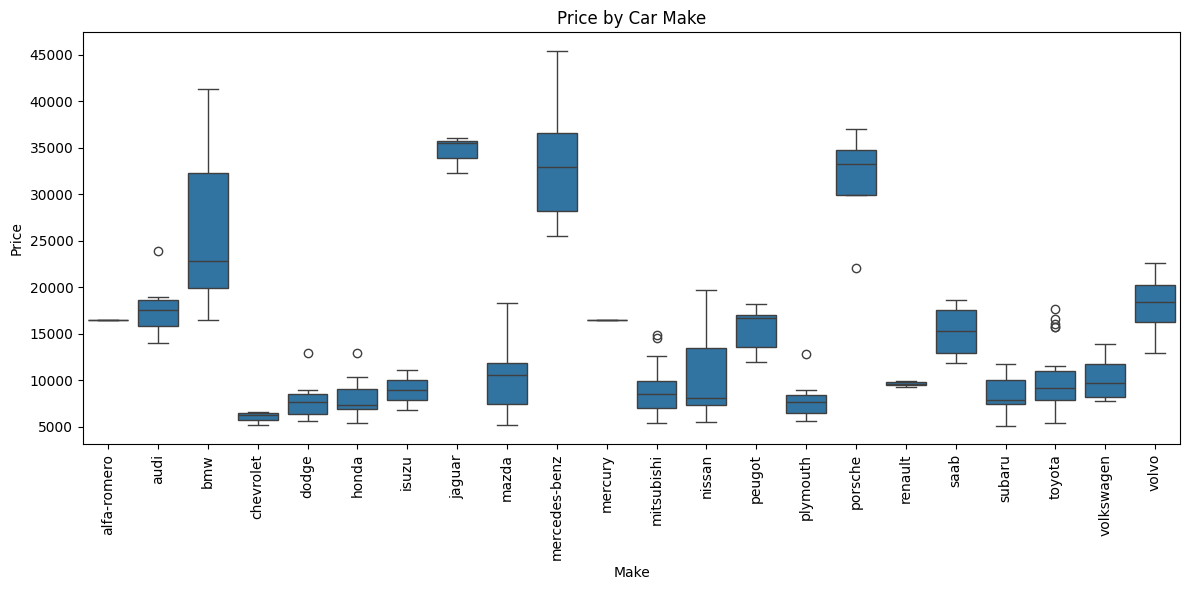

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='make', y='price', data=df)
plt.xticks(rotation=90)
plt.title('Price by Car Make')
plt.xlabel('Make')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
results = []

print("Preprocessing complete. Training set size:", X_train.shape[0])

Preprocessing complete. Training set size: 160


Linear regression

In [ ]:
model_lr = LinearRegression()

In [ ]:
model_lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
preds_lr = model_lr.predict(X_test)

In [ ]:
mse_lr = mean_squared_error(y_test, preds_lr)
r2_lr = r2_score(y_test, preds_lr)
rmse_lr = np.sqrt(mse_lr)

In [ ]:
results.append({"Model": "Linear", "MSE": mse_lr, "R2": r2_lr, "RMSE": rmse_lr})

print(f"Linear Regression ->\n R2: {r2_lr:.4f},\n MSE: {mse_lr:.2f},\n RMSE: {rmse_lr:.2f}")

Linear Regression ->
 R2: 0.8750,
 MSE: 14007858.67,
 RMSE: 3742.71


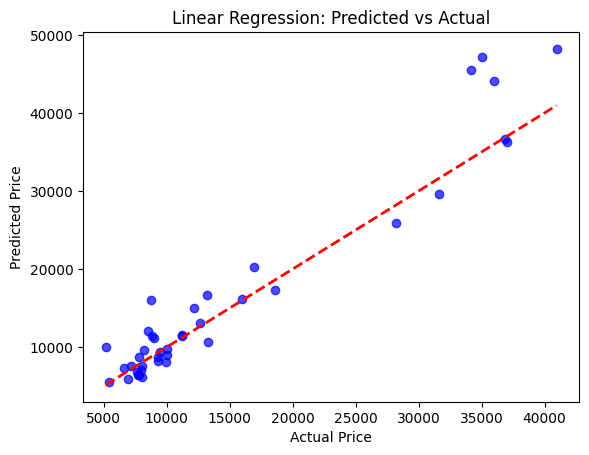

In [ ]:
plt.scatter(y_test, preds_lr, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Linear Regression: Predicted vs Actual")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [ ]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
preds_ridge = model_ridge.predict(X_test)

In [ ]:
mse_ridge = mean_squared_error(y_test, preds_ridge)
r2_ridge = r2_score(y_test, preds_ridge)
rmse_ridge = np.sqrt(mse_ridge)

In [ ]:
results.append({"Model": "Ridge", "MSE": mse_ridge, "R2": r2_ridge, "RMSE": rmse_ridge})

In [ ]:
print(f"Ridge Regression -> R2: {r2_ridge:.4f}, MSE: {mse_ridge:.2f}, RMSE: {rmse_ridge:.2f}")

Ridge Regression -> R2: 0.9304, MSE: 7794482.02, RMSE: 2791.86


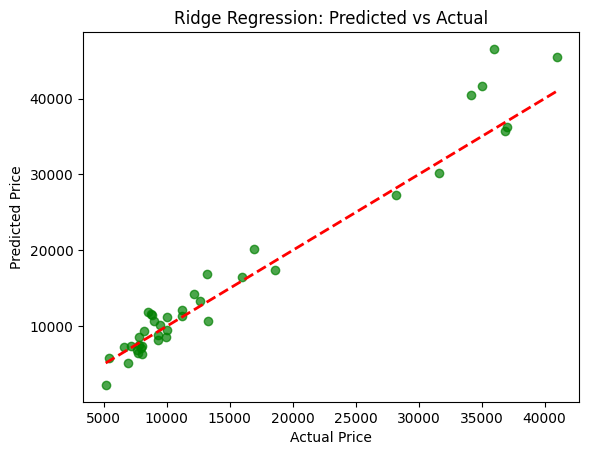

In [ ]:
plt.scatter(y_test, preds_ridge, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Ridge Regression: Predicted vs Actual")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [ ]:
model_lasso = Lasso(alpha=1.0, max_iter=10000)
model_lasso.fit(X_train, y_train)
preds_lasso = model_lasso.predict(X_test)

In [ ]:
mse_lasso = mean_squared_error(y_test, preds_lasso)
r2_lasso = r2_score(y_test, preds_lasso)
rmse_lasso = np.sqrt(mse_lasso)

In [ ]:
results.append({"Model": "Lasso", "MSE": mse_lasso, "R2": r2_lasso, "RMSE": rmse_lasso})

In [ ]:
print(f"Lasso Regression -> R2: {r2_lasso:.4f}, MSE: {mse_lasso:.2f}, RMSE: {rmse_lasso:.2f}")

Lasso Regression -> R2: 0.8831, MSE: 13094871.04, RMSE: 3618.68


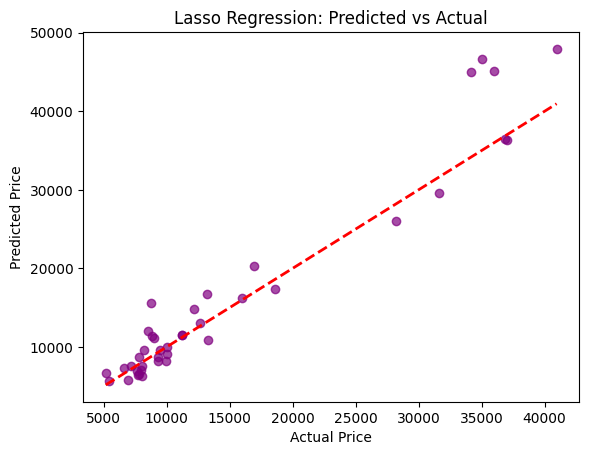

In [ ]:
plt.scatter(y_test, preds_lasso, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Lasso Regression: Predicted vs Actual")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

### Decision Tree Regressor

In [ ]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)
preds_dt = model_dt.predict(X_test)

In [ ]:
mse_dt = mean_squared_error(y_test, preds_dt)
r2_dt = r2_score(y_test, preds_dt)
rmse_dt = np.sqrt(mse_dt)
results.append({"Model": "Decision Tree", "MSE": mse_dt, "R2": r2_dt, "RMSE": rmse_dt})
print(f"Decision Tree Regressor -> R2: {r2_dt:.4f}, MSE: {mse_dt:.2f}, RMSE: {rmse_dt:.2f}")

Decision Tree Regressor -> R2: 0.9217, MSE: 8770303.55, RMSE: 2961.47


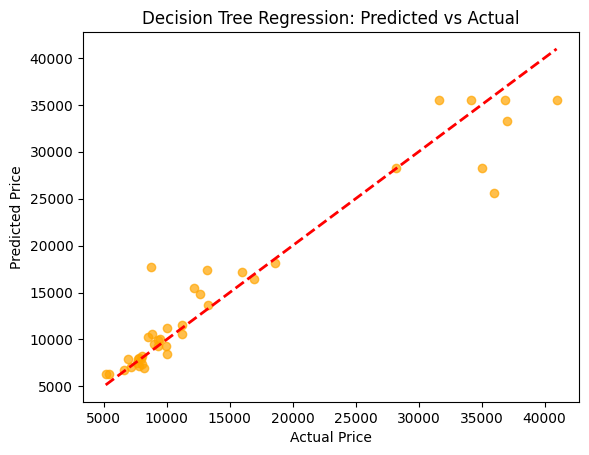

In [ ]:
plt.scatter(y_test, preds_dt, alpha=0.7, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Decision Tree Regression: Predicted vs Actual")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

### Random Forest Regressor

In [ ]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)
preds_rf = model_rf.predict(X_test)

In [ ]:
mse_rf = mean_squared_error(y_test, preds_rf)
r2_rf = r2_score(y_test, preds_rf)
rmse_rf = np.sqrt(mse_rf)
results.append({"Model": "Random Forest", "MSE": mse_rf, "R2": r2_rf, "RMSE": rmse_rf})
print(f"Random Forest Regressor -> R2: {r2_rf:.4f}, MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}")

Random Forest Regressor -> R2: 0.9685, MSE: 3533105.77, RMSE: 1879.66


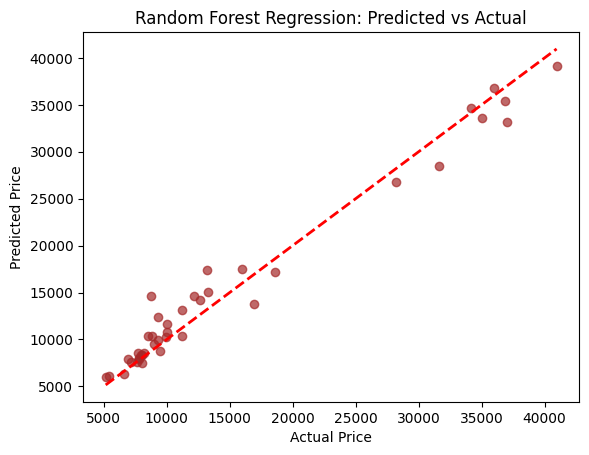

In [ ]:
plt.scatter(y_test, preds_rf, alpha=0.7, color='brown')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Random Forest Regression: Predicted vs Actual")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

### Final Model Comparison

In [ ]:
print("\nFinal Model Comparison Summary:")
display(comparison_df)


Final Model Comparison Summary:


,Model,MSE,R2,RMSE
0,Linear,1.400786e+07,0.874984,3742.707399
1,Ridge,7.794482e+06,0.930436,2791.859958
2,Lasso,1.309487e+07,0.883132,3618.683605
3,Decision Tree,8.770304e+06,0.921727,2961.469829
4,Random Forest,3.533106e+06,0.968468,1879.655759


/tmp/ipykernel_6578/3386305981.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=comparison_df, palette='magma')


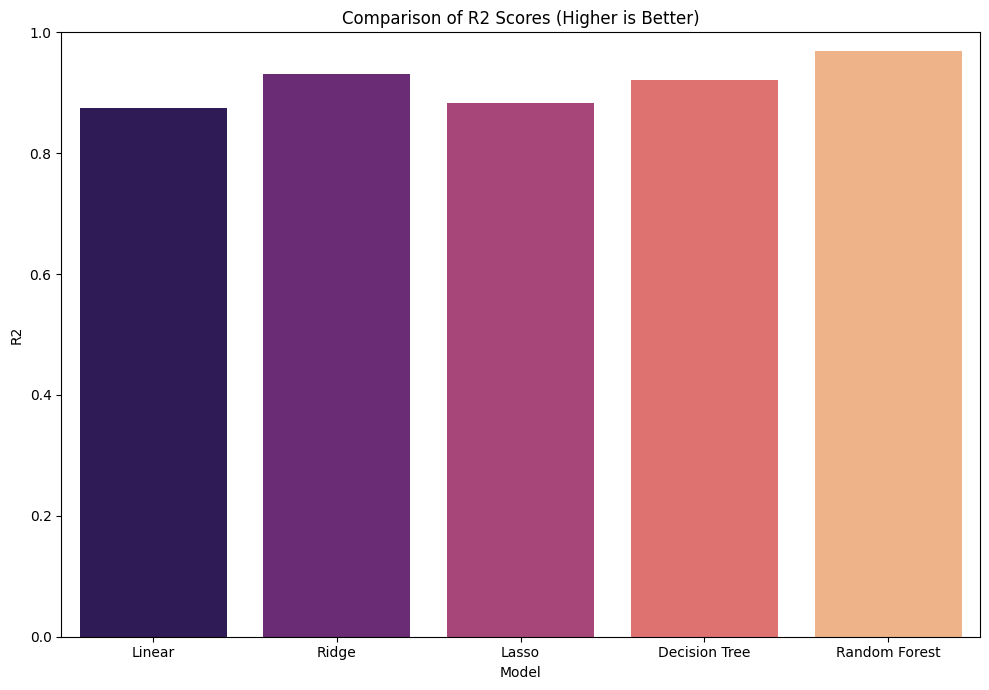

In [ ]:
comparison_df = pd.DataFrame(results)

plt.figure(figsize=(10, 7))
sns.barplot(x='Model', y='R2', data=comparison_df, palette='magma')
plt.title("Comparison of R2 Scores (Higher is Better)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6578/3137539501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=comparison_df, palette='viridis')


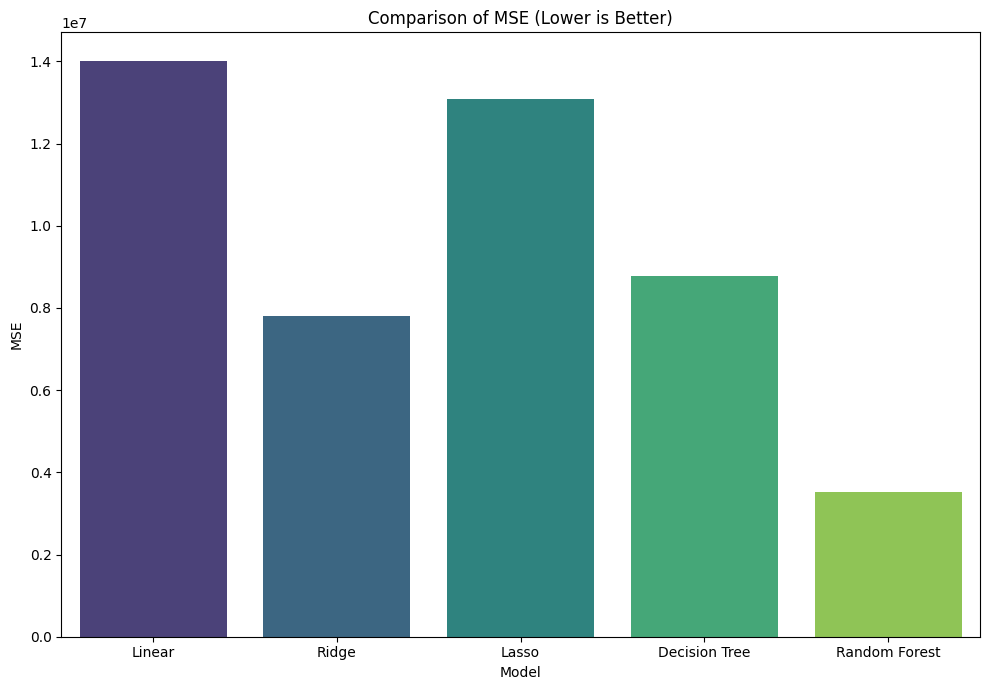

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Model', y='MSE', data=comparison_df, palette='viridis')
plt.title("Comparison of MSE (Lower is Better)")
plt.tight_layout()
plt.show()